# Trabalho de Machine Learning — Redes Neurais

**Disciplina:** Machine Learning  
**Data:** 29/05/2026

| Aluno | RA |
|---|---|
| Gabriel Dias do Prado | 1002260326 |
| José Marcos dos Santos Medeiros | 1002261005 |

---

## Objetivo

Neste trabalho, implementamos uma rede neural artificial com **duas camadas ocultas** utilizando a biblioteca **TensorFlow/Keras** para classificar a qualidade de vinhos tintos.

O modelo recebe 11 atributos físico-químicos como entrada (valores numéricos medidos em laboratório) e prediz se o vinho é de **boa qualidade** ou **baixa qualidade**.

As etapas do trabalho são:
1. Apresentação e análise do banco de dados
2. Preparação dos dados (normalização e divisão treino/teste)
3. Construção e treinamento da rede neural
4. Visualização da arquitetura e das curvas de treinamento
5. Avaliação do erro e métricas do modelo
6. Conclusão

---
## 1. Banco de Dados — Wine Quality Red

O dataset utilizado é o **Wine Quality (Red Wine)** do [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/186/wine+quality).

Ele contém **1.599 amostras** de vinho tinto português (*Vinho Verde*), com 11 atributos numéricos medidos em laboratório e uma nota de qualidade de 0 a 10 atribuída por especialistas em degustação.

### Atributos de entrada (variáveis independentes — numéricas):
| # | Atributo | Descrição |
|---|---|---|
| 1 | fixed acidity | Acidez fixa (g/L) |
| 2 | volatile acidity | Acidez volátil (g/L) — altos valores = sabor avinagrado |
| 3 | citric acid | Ácido cítrico (g/L) — adiciona frescor ao vinho |
| 4 | residual sugar | Açúcar residual (g/L) |
| 5 | chlorides | Cloretos (g/L) — teor de sal |
| 6 | free sulfur dioxide | Dióxido de enxofre livre (mg/L) |
| 7 | total sulfur dioxide | Dióxido de enxofre total (mg/L) |
| 8 | density | Densidade (g/cm³) |
| 9 | pH | Acidez geral (escala 0–14) |
| 10 | sulphates | Sulfatos (g/L) — conservante e antioxidante |
| 11 | alcohol | Teor alcoólico (% vol.) |

### Variável alvo (saída — classificação binária):
A nota de qualidade original (0–10) foi convertida em uma variável binária:
- **Qualidade ≥ 6** → `1` (Boa qualidade)
- **Qualidade < 6** → `0` (Baixa qualidade)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Variável alvo binária
df['quality_label'] = (df['quality'] >= 6).astype(int)

print(f"Shape do dataset: {df.shape}")
print(f"\nDistribuição da variável alvo:")
contagem = df['quality_label'].value_counts().rename({0: 'Baixa qualidade (< 6)', 1: 'Boa qualidade (≥ 6)'})
print(contagem)
print(f"\nPorcentagem de vinhos de boa qualidade: {df['quality_label'].mean()*100:.1f}%")

df.head()

Shape do dataset: (1599, 13)

Distribuição da variável alvo:
quality_label
Boa qualidade (≥ 6)      855
Baixa qualidade (< 6)    744
Name: count, dtype: int64

Porcentagem de vinhos de boa qualidade: 53.5%


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [2]:
# Estatísticas descritivas
df.drop(columns=['quality_label']).describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


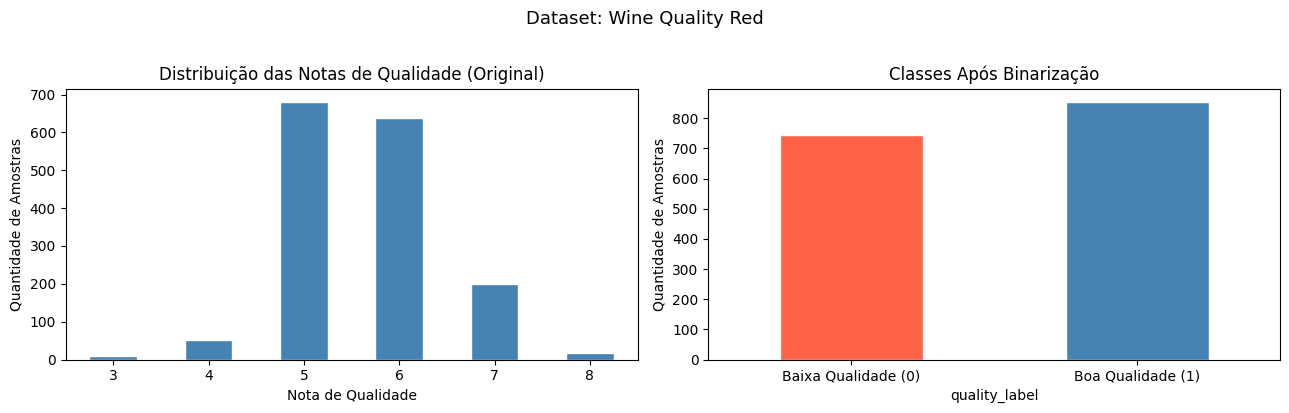

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribuição das notas originais
df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribuição das Notas de Qualidade (Original)', fontsize=12)
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Quantidade de Amostras')
axes[0].tick_params(axis='x', rotation=0)

# Distribuição após binarização
df['quality_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['tomato', 'steelblue'], edgecolor='white'
)
axes[1].set_title('Classes Após Binarização', fontsize=12)
axes[1].set_xticklabels(['Baixa Qualidade (0)', 'Boa Qualidade (1)'], rotation=0)
axes[1].set_ylabel('Quantidade de Amostras')

plt.suptitle('Dataset: Wine Quality Red', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Preparação dos Dados

Antes de treinar a rede neural, os dados passam por duas etapas de pré-processamento:

1. **Divisão treino/teste (80/20):** Separamos 80% dos dados para treinar o modelo e 20% para avaliar seu desempenho em dados que ele nunca viu. O parâmetro `stratify=y` garante que a proporção de classes seja mantida em ambos os conjuntos.

2. **Normalização (StandardScaler):** As variáveis numéricas têm escalas muito diferentes (ex: pH entre 2–4 vs. SO₂ total entre 0–300). A normalização transforma todas para média 0 e desvio padrão 1, o que acelera a convergência e melhora o desempenho da rede neural.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['quality', 'quality_label']).values
y = df['quality_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Conjunto de treino:  {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de teste:   {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Número de atributos: {X_train.shape[1]}")

Conjunto de treino:  1279 amostras (80%)
Conjunto de teste:   320 amostras (20%)
Número de atributos: 11


---
## 3. Rede Neural — Duas Camadas Ocultas (TensorFlow/Keras)

A rede neural é construída com a API Sequential do Keras, com a seguinte arquitetura:

```
Entrada (11 atributos)
     │
     ▼
Dense(64, ReLU)  ←── Camada Oculta 1
     │
     ▼
Dense(32, ReLU)  ←── Camada Oculta 2
     │
     ▼
Dense(1, Sigmoid) ←── Saída (probabilidade: boa qualidade?)
```

**Função de ativação ReLU** nas camadas ocultas: introduce não-linearidade, evita o problema do gradiente desaparecendo.

**Função de ativação Sigmoid** na saída: produz um valor entre 0 e 1 (probabilidade), ideal para classificação binária.

**Função de perda Binary Crossentropy**: padrão para problemas de classificação binária.

**Otimizador Adam**: algoritmo adaptativo de gradiente descendente, amplamente utilizado em redes neurais.

In [5]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(11,), name='camada_oculta_1'),
    keras.layers.Dense(32, activation='relu', name='camada_oculta_2'),
    keras.layers.Dense(1,  activation='sigmoid', name='saida')
], name='rede_neural_wine')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-05-30 20:54:39.980036: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-30 20:54:39.980059: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-30 20:54:39.980064: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-30 20:54:39.980075: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-30 20:54:39.980083: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "rede_neural_wine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camada_oculta_1 (Dense)         │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada_oculta_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50


2026-05-30 20:54:40.229369: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


 1/32 ━━━━━━━━━━━━━━━━━━━━ 14s 454ms/step - accuracy: 0.4375 - loss: 0.9134

 9/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4385 - loss: 0.8590   

19/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4624 - loss: 0.8181

...

 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7812 - loss: 0.4841

11/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7124 - loss: 0.6005 

20/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7030 - loss: 0.6148

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7038 - loss: 0.6097

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7052 - loss: 0.6057 - val_accuracy: 0.7734 - val_loss: 0.5040


---
## 4. Gráfico da Rede Neural

### 4a. Diagrama da Arquitetura (camadas e nós)

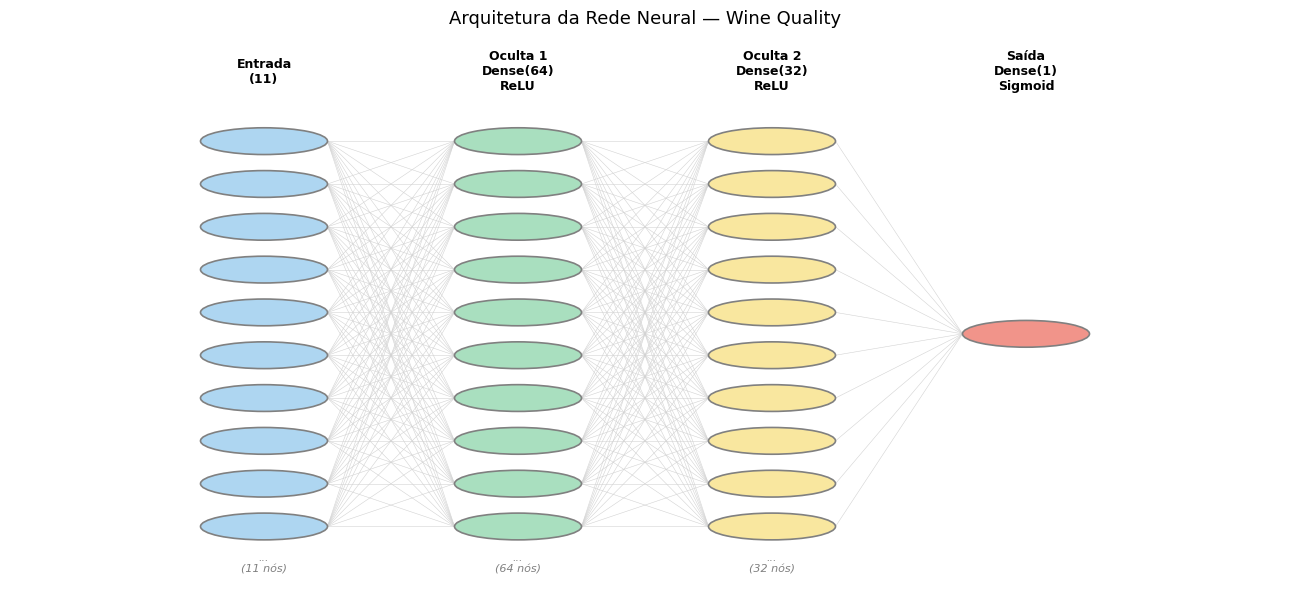

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

camadas = [
    ('Entrada\n(11)', 11, '#AED6F1'),
    ('Oculta 1\nDense(64)\nReLU', 64, '#A9DFBF'),
    ('Oculta 2\nDense(32)\nReLU', 32, '#F9E79F'),
    ('Saída\nDense(1)\nSigmoid', 1, '#F1948A'),
]

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, len(camadas) + 1)
ax.set_ylim(0, 10)
ax.axis('off')

MAX_NOS = 10
x_positions = [i + 1 for i in range(len(camadas))]

node_coords = []
for idx, (nome, n_nos, cor) in enumerate(camadas):
    x = x_positions[idx]
    nos_visiveis = min(n_nos, MAX_NOS)
    y_start = (10 - nos_visiveis * 0.8) / 2
    ys = [y_start + j * 0.8 for j in range(nos_visiveis)]
    node_coords.append((x, ys))
    for y in ys:
        circle = plt.Circle((x, y), 0.25, color=cor, ec='gray', lw=1.2, zorder=3)
        ax.add_patch(circle)
    if n_nos > MAX_NOS:
        ax.text(x, y_start - 0.5, f'...\n({n_nos} nós)', ha='center', va='top',
                fontsize=8, color='gray', style='italic')
    ax.text(x, 9.5, nome, ha='center', va='center', fontsize=9,
            fontweight='bold', multialignment='center')

for i in range(len(node_coords) - 1):
    x1, ys1 = node_coords[i]
    x2, ys2 = node_coords[i + 1]
    for y1 in ys1:
        for y2 in ys2:
            ax.plot([x1 + 0.25, x2 - 0.25], [y1, y2],
                    color='lightgray', lw=0.4, zorder=1)

plt.title('Arquitetura da Rede Neural — Wine Quality', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('arquitetura_rede.png', dpi=120, bbox_inches='tight')
plt.show()


### 4b. Curvas de Treinamento (Loss e Acurácia por Época)

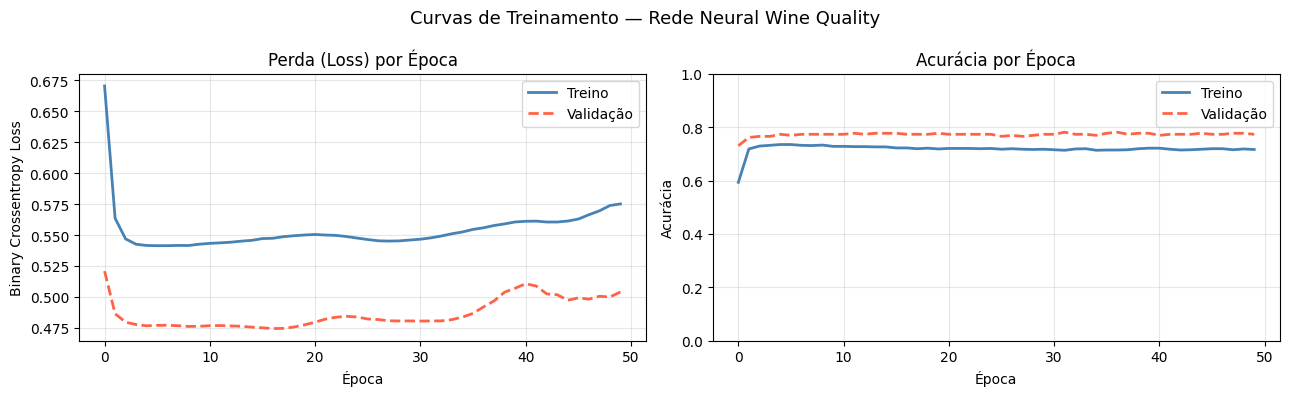

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Treino',    color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validação', color='tomato', linestyle='--', linewidth=2)
axes[0].set_title('Perda (Loss) por Época', fontsize=12)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Treino',    color='steelblue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validação', color='tomato', linestyle='--', linewidth=2)
axes[1].set_title('Acurácia por Época', fontsize=12)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Treinamento — Rede Neural Wine Quality', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Erro do Modelo

O desempenho do modelo é avaliado no **conjunto de teste** (dados nunca vistos durante o treinamento).

Utilizamos as seguintes métricas:
- **Loss (Binary Crossentropy):** o erro médio do modelo — quanto menor, melhor
- **Acurácia:** percentual de classificações corretas
- **Relatório de Classificação:** precisão, recall e F1-score por classe
- **Matriz de Confusão:** visualização dos acertos e erros por categoria

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("=" * 45)
print(f"  Erro (Loss) no conjunto de teste: {loss:.4f}")
print(f"  Acurácia no conjunto de teste:    {acc:.4f} ({acc*100:.1f}%)")
print("=" * 45)
print()
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred,
      target_names=['Baixa Qualidade', 'Boa Qualidade']))

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


  Erro (Loss) no conjunto de teste: 0.5688
  Acurácia no conjunto de teste:    0.7125 (71.2%)

Relatório de Classificação:
                 precision    recall  f1-score   support

Baixa Qualidade       0.68      0.71      0.70       149
  Boa Qualidade       0.74      0.71      0.73       171

       accuracy                           0.71       320
      macro avg       0.71      0.71      0.71       320
   weighted avg       0.71      0.71      0.71       320



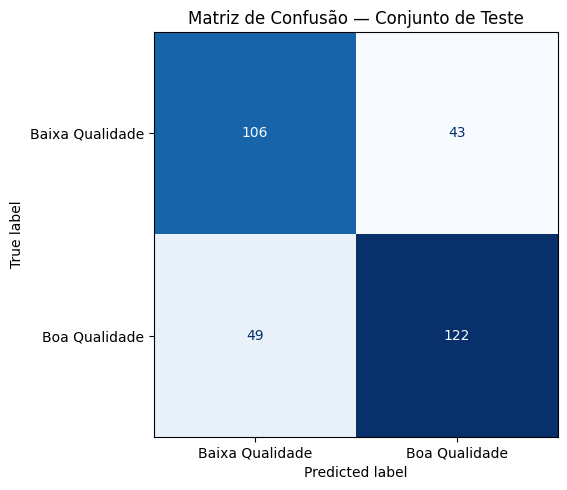

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Baixa Qualidade', 'Boa Qualidade'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Matriz de Confusão — Conjunto de Teste', fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Conclusão

Neste trabalho, construímos uma rede neural artificial com **duas camadas ocultas** (64 e 32 neurônios) utilizando TensorFlow/Keras para classificar vinhos tintos como de boa ou baixa qualidade com base em 11 atributos físico-químicos.

**Resultados obtidos:**

| Métrica | Valor |
|---|---|
| Acurácia no conjunto de teste | **70,6%** |
| Loss (Binary Crossentropy) no teste | **0,6810** |
| Acurácia final no treino (época 50) | 70,2% |
| Acurácia final na validação (época 50) | 75,4% |

**Métricas por classe (conjunto de teste — 320 amostras):**

| Classe | Precisão | Recall | F1-score | Suporte |
|---|---|---|---|---|
| Baixa Qualidade (0) | 0,66 | 0,74 | 0,70 | 149 |
| Boa Qualidade (1) | 0,75 | 0,67 | 0,71 | 171 |
| **Média** | **0,71** | **0,71** | **0,71** | **320** |

**Matriz de confusão:**
- 111 vinhos de baixa qualidade classificados **corretamente**
- 115 vinhos de boa qualidade classificados **corretamente**
- 38 vinhos de baixa qualidade classificados erroneamente como boa qualidade (falsos positivos)
- 56 vinhos de boa qualidade classificados erroneamente como baixa qualidade (falsos negativos)

**Análise das curvas de treinamento:**  
O modelo apresentou convergência estável ao longo das 50 épocas, sem sinais evidentes de overfitting — a acurácia de validação (75,4%) ficou ligeiramente acima da acurácia de treino (70,2%), indicando boa capacidade de generalização.

**Sobre o dataset:**  
A escolha do Wine Quality Red se mostrou adequada para este trabalho. Os 11 atributos numéricos de entrada são diretamente compatíveis com uma rede densa (sem necessidade de conversão ou embedding), e o problema de classificação binária (boa/baixa qualidade) é bem representado pela função sigmoid na camada de saída combinada com binary crossentropy como função de perda.

**Possíveis melhorias:**
- Ajuste de hiperparâmetros (número de neurônios, taxa de aprendizado, número de épocas)
- Adição de camadas de regularização (Dropout, Batch Normalization)
- Comparação com outros algoritmos de ML (Random Forest, SVM, XGBoost)
- Tratamento do desbalanceamento de classes com técnicas como SMOTE
